In [ ]:
import gensim.downloader as api
from numpy import dot
from numpy.linalg import norm

In [ ]:
model=api.load('word2vec-google-news-300')
model
len(model)
print(model.index_to_key[:10])

['</s>', 'in', 'for', 'that', 'is', 'on', '##', 'The', 'with', 'said']


In [ ]:
king_vector=model['king']
man_vector=model['man']
women_vector=model['woman']
result_vector= king_vector - man_vector + women_vector
#not required but to check the result of the vector operation
result=model.most_similar(positive=['king', 'woman'], negative=['man'], topn=2)
print(f'result of king - man + woman: {result[0][0]}')
print(f'result of king - man + woman: {result[0][1]}')
print(f'result of king - man + woman: {result[1][0]}')
print(f'result of king - man + woman: {result[1][1]}')
#till here
queen_vector=model['queen']
cosine_sim=dot(result_vector, queen_vector) / (norm(result_vector) * norm(queen_vector))
print(f'Cosine similarity between king - man + woman and queen: {cosine_sim}')

result of king - man + woman: queen
result of king - man + woman: 0.7118191123008728
result of king - man + woman: monarch
result of king - man + woman: 0.6189674735069275
Cosine similarity between king - man + woman and queen: 0.7300516963005066


PROGRAM 2

In [ ]:
words=['data','science','machine','learning','artificial','intelligence','deep','neural','network','algorithm']
embeddings = [model[word] for word in words]
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
embeddings_matrix = np.array(embeddings)

varience explained by PCA: 37.8%


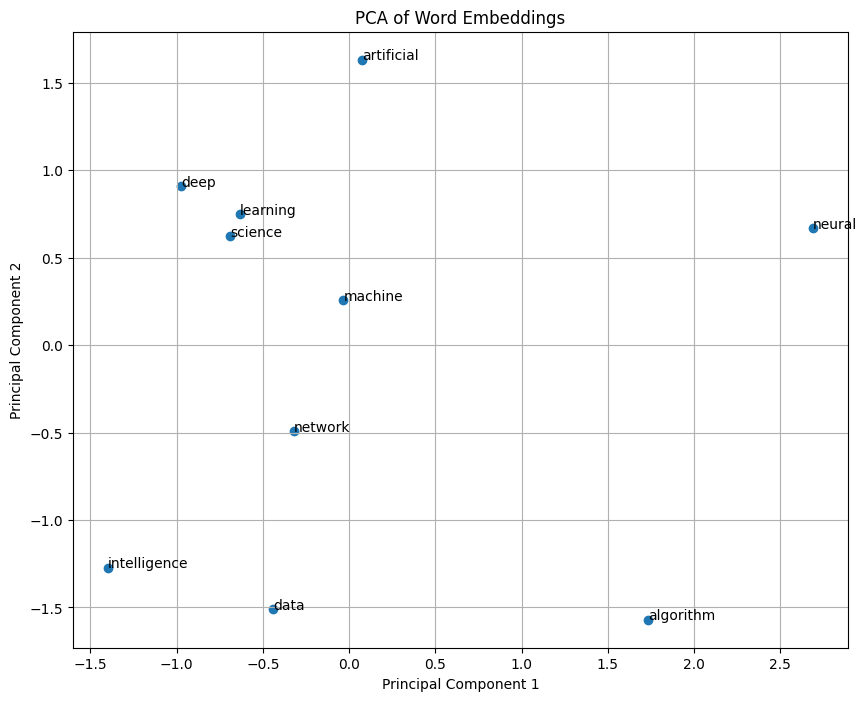

In [ ]:
pca=PCA(n_components=2)
reduced_pca=pca.fit_transform(embeddings_matrix)
print(f'varience explained by PCA: {sum(pca.explained_variance_ratio_)*100:.1f}%')
plt.figure(figsize=(10, 8))
plt.scatter(reduced_pca[:, 0], reduced_pca[:, 1])
for i in range(len(words)):
    plt.text(reduced_pca[i, 0], reduced_pca[i, 1], words[i])
plt.title('PCA of Word Embeddings')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid()
plt.show()

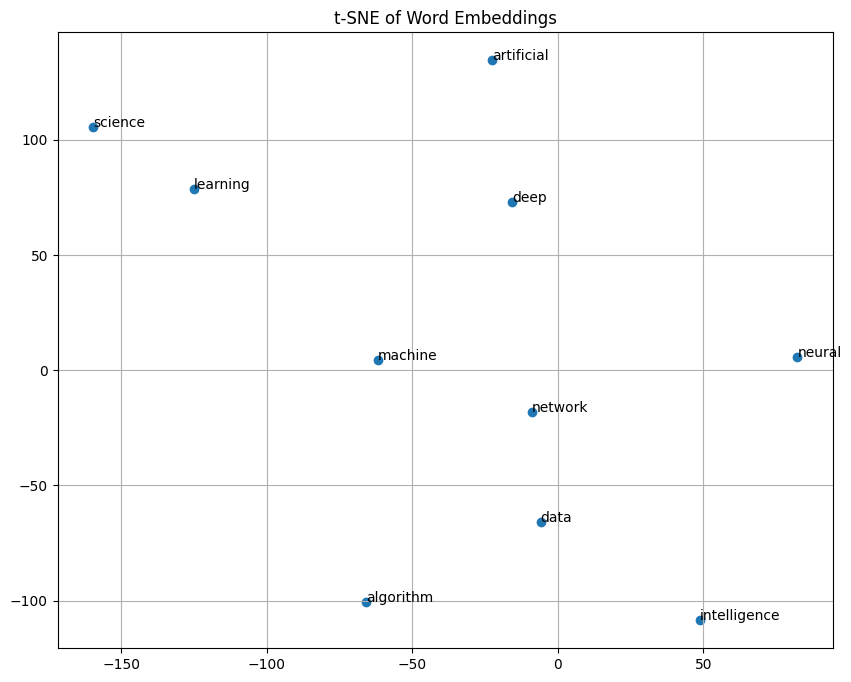

In [ ]:
tsne=TSNE(n_components=2, random_state=42,perplexity=3)
reduced_tsne=tsne.fit_transform(embeddings_matrix) 
plt.figure(figsize=(10, 8))
plt.scatter(reduced_tsne[:, 0], reduced_tsne[:, 1])
for i in range(len(words)):
    plt.text(reduced_tsne[i, 0], reduced_tsne[i, 1], words[i])
plt.title('t-SNE of Word Embeddings')
plt.grid()
plt.show()

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
cosine_sim=cosine_similarity(embeddings)
#matrix_shape=
pairs=[]
for i in range(len(words)):
    for j in range(i+1, len(words)):
        pairs.append((words[i], words[j], cosine_sim[i][j]))
for word1, word2, sim in pairs:
    print(f'Cosine similarity between "{word1}" and "{word2}": {sim:.4f}')

Cosine similarity between "data" and "science": 0.1576
Cosine similarity between "data" and "machine": 0.1143
Cosine similarity between "data" and "learning": 0.1056
Cosine similarity between "data" and "artificial": 0.0092
Cosine similarity between "data" and "intelligence": 0.3275
Cosine similarity between "data" and "deep": 0.0154
Cosine similarity between "data" and "neural": 0.1837
Cosine similarity between "data" and "network": 0.3113
Cosine similarity between "data" and "algorithm": 0.3473
Cosine similarity between "science" and "machine": 0.0803
Cosine similarity between "science" and "learning": 0.2866
Cosine similarity between "science" and "artificial": 0.1849
Cosine similarity between "science" and "intelligence": 0.1641
Cosine similarity between "science" and "deep": 0.0765
Cosine similarity between "science" and "neural": 0.1865
Cosine similarity between "science" and "network": 0.0545
Cosine similarity between "science" and "algorithm": 0.1497
Cosine similarity between "

In [ ]:
def similar5(input,n=5):
    result=model.most_similar(input,topn=n)
    print(f'Top {n} words similar to "{input}":')
    for word,sim in result:
        print(f'{word}: {sim:.4f}')
print(similar5('data'))
print(similar5('science'))

Top 5 words similar to "data":
Data: 0.7262
datasets: 0.6030
dataset: 0.5797
databases: 0.5450
statistics: 0.5379
None
Top 5 words similar to "science":
faith_Jezierski: 0.6965
sciences: 0.6821
biology: 0.6776
scientific: 0.6535
mathematics: 0.6301
None
